<a href="https://colab.research.google.com/github/Angeltt251/Evaluacion_U1_Flores_jose/blob/main/Evaluaci%C3%B3n_U1_Flores_jose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Evaluación Final Unidad I — proyecto CRISP-DM
**IEI-097 Minería de Datos · Actividad 1.9**

| | |
|---|---|
| **Nombre** | José Miguel Flores Chávez |
| **Carrera / Sede / Sección** | Ingeniería en Informática · Instituto Profesional Santo Tomás, Arica  |
| **Dataset** | Wine Quality (vino blanco) — Kaggle: `willianoliveiragibin/modeling-wine`, archivo `winequality-white new.csv` |


# A. El problema
**Fase CRISP-DM:** Comprensión del negocio *(Business Understanding)*

**Contexto:** el dataset reúne mediciones fisicoquímicas de vinos blancos (acidez, azúcar, alcohol, densidad, etc.) y una nota de calidad asignada por catadores. Podría usarlo una bodega o un equipo de enología.

**Objetivo:** apoyar la decisión de *qué características químicas conviene controlar durante la producción para aumentar la probabilidad de obtener un vino de calidad alta*.

**¿Por qué minería de datos y no solo una consulta o un promedio?** Un promedio de calidad no dice qué *combinaciones* de características se asocian a los buenos vinos. Las reglas de asociación encuentran combinaciones frecuentes y el árbol de decisión las organiza como reglas de clasificación.

 **TU INTERPRETACIÓN:** reescribe este texto con tus palabras y ajusta el objetivo si quieres enfocarlo distinto.

# B. Los datos
**Fase CRISP-DM:** Comprensión de los datos *(Data Understanding)*

In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Sube aquí el archivo "winequality-white new.csv" descargado de Kaggle
subido = files.upload()
nombre_archivo = list(subido.keys())[0]

# sep=None detecta automáticamente si el separador es coma o punto y coma
df = pd.read_csv(nombre_archivo, sep=None, engine='python')
# Normalizo nombres: minúsculas y guion bajo (ej. 'fixed acidity' -> 'fixed_acidity')
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

print("Dimensiones (filas, columnas):", df.shape)
df.head()

Saving winequality-white new.csv to winequality-white new.csv
Dimensiones (filas, columnas): (4898, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,quality,alcohol
0,7.0,0.27,0.36,20.7,45.00,45.0,170.0,1.001,3.00,0.45,6,"R$ 45.512,00"
1,6.3,0.30,0.34,1.6,49.00,14.0,132.0,994.000,3.30,0.49,6,"R$ 45.421,00"
2,8.1,0.28,0.40,6.9,0.05,30.0,97.0,9.951,3.26,0.44,6,"R$ 45.301,00"
3,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,"R$ 45.544,00"
4,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,"R$ 45.544,00"


**Fuente:** Cortez, P., Cerdeira, A., Almeida, F., Matos, T., Reis, J. (2009). *Modeling wine preferences by data mining from physicochemical properties.* Dataset original en UCI Machine Learning Repository (Wine Quality); copia en Kaggle: `willianoliveiragibin/modeling-wine`.
**Licencia:** *(revisa y anota la licencia que aparece en la página de Kaggle; el dataset original de UCI se distribuye bajo CC BY 4.0)*.

### Diccionario de atributos
**TU INTERPRETACIÓN:** la columna "Por qué es importante" es un borrador. Reescríbela con tus palabras y revisa que los nombres coincidan con tu archivo.

| # | Atributo | Tipo | Por qué es importante para mi objetivo |
|---|---|---|---|
| 1 | `fixed_acidity` | numérico | Acidez no volátil; influye en el sabor y la estabilidad del vino. |
| 2 | `volatile_acidity` | numérico | Exceso de acidez volátil da sabor avinagrado; suele asociarse a menor calidad. |
| 3 | `citric_acid` | numérico | Aporta frescor; ayuda a ver cómo la acidez se relaciona con la calidad. |
| 4 | `residual_sugar` | numérico | Azúcar que queda tras la fermentación; define el estilo (seco/dulce). |
| 5 | `chlorides` | numérico | Sal en el vino; valores altos pueden afectar el sabor. |
| 6 | `free_sulfur_dioxide` | numérico | Conservante activo; protege contra oxidación y microbios. |
| 7 | `total_sulfur_dioxide` | numérico | Total de SO₂; en exceso se nota en olor y sabor. |
| 8 | `density` | numérico | Se relaciona con alcohol y azúcar; permite controlar la fermentación. |
| 9 | `ph` | numérico | Nivel de acidez general; afecta estabilidad y sabor. |
| 10 | `sulphates` | numérico | Aditivo antimicrobiano/antioxidante; se asocia a la conservación. |
| 11 | `alcohol` | numérico | Suele ser uno de los factores más ligados a la calidad percibida. |
| 12 | `quality` | numérico (ordinal) | Nota de los catadores; es la base de mi variable objetivo. |

# C. Exploración y preparación (EDA)
**Fases CRISP-DM:** Comprensión de los datos *(EDA)* y Preparación de los datos *(limpieza y descarte)*

In [ ]:
# Estructura y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         4898 non-null   float64
 1   volatile_acidity      4898 non-null   float64
 2   citric_acid           4898 non-null   float64
 3   residual_sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free_sulfur_dioxide   4898 non-null   float64
 6   total_sulfur_dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   ph                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  quality               4898 non-null   int64  
 11  alcohol               4898 non-null   object 
dtypes: float64(10), int64(1), object(1)
memory usage: 459.3+ KB


In [ ]:
# Valores nulos y duplicados
print("Nulos por columna:")
print(df.isna().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

In [ ]:
# Estadística descriptiva
df.describe().T

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


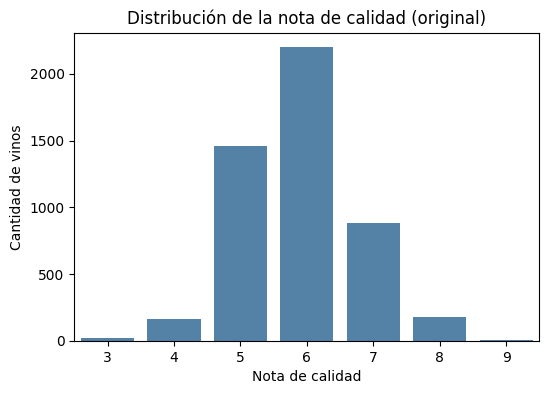

In [ ]:
# Distribución de la nota original de calidad
print(df['quality'].value_counts().sort_index())
plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=df, color='steelblue')
plt.title('Distribución de la nota de calidad (original)')
plt.xlabel('Nota de calidad'); plt.ylabel('Cantidad de vinos')
plt.show()

**TU INTERPRETACIÓN (hallazgos del EDA):** ¿cuántas filas y columnas hay? ¿hay nulos? ¿cuántos duplicados? ¿qué notas son más frecuentes y cuáles casi no aparecen (desbalance)? ¿ves rangos o valores extraños en `describe()` (por ejemplo máximos muy lejos de la media en `residual_sugar` o `free_sulfur_dioxide`)?

In [ ]:
# Preparación: elimino duplicados y creo la variable objetivo categórica (3 clases)
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Filas antes: {n_antes} | después de quitar duplicados: {len(df)}")

# 'quality' original tiene ~7 clases; la agrupo para cumplir el requisito de 2 a 5 clases
df['calidad_grupo'] = pd.cut(df['quality'], bins=[0, 5, 6, 10], labels=['baja', 'media', 'alta'])
print(df['calidad_grupo'].value_counts())
print((df['calidad_grupo'].value_counts(normalize=True) * 100).round(1))

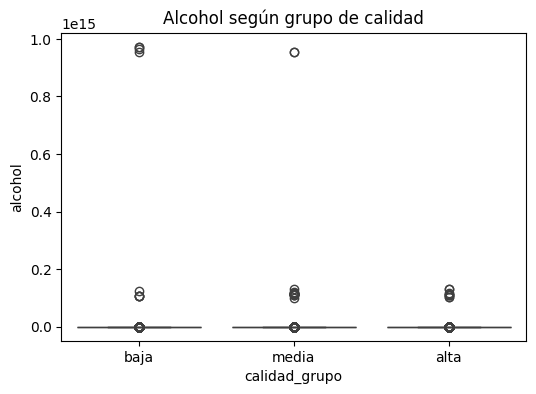

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for pd.cut

# Data preparation steps to ensure 'alcohol' is numeric and 'calidad_grupo' exists
# Clean 'alcohol' column by removing currency symbols, thousand separators, and replacing decimal comma, then convert to float
df['alcohol'] = df['alcohol'].astype(str).str.replace('R\\$', '', regex=True).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).str.strip().astype(float)

# Create 'calidad_grupo' column if it doesn't exist
# Ensure 'quality' column is available for this step
if 'quality' in df.columns:
    df['calidad_grupo'] = pd.cut(df['quality'], bins=[0, 5, 6, 10], labels=['baja', 'media', 'alta'])
else:
    print("Error: 'quality' column not found, cannot create 'calidad_grupo'.")

# Visualización 1: alcohol según grupo de calidad
plt.figure(figsize=(6,4))
sns.boxplot(x='calidad_grupo', y='alcohol', data=df, order=['baja','media','alta'])
plt.title('Alcohol según grupo de calidad')
plt.show()

In [ ]:
# Visualización 2: matriz de correlación entre variables numéricas
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=['calidad_grupo']).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre variables numéricas')
plt.show()

**texto en negrita**> **TU INTERPRETACIÓN (visualizaciones y decisiones):**
> - ¿Qué muestra el boxplot? ¿el alcohol cambia entre calidad baja y alta?
> - ¿Qué pares de variables están muy correlacionados (ej. `density` con `alcohol` y `residual_sugar`)?
> - **Justifica cada decisión:** por qué eliminaste duplicados, por qué agrupaste `quality` en 3 clases y por qué elegiste esos cortes (≤5, 6, ≥7). Menciona que el dataset no tenía nulos *(confírmalo con tu salida)*.

# D. Reglas de asociación
**Fase CRISP-DM:** Modelado *(Modeling)*

Las reglas de asociación trabajan con **ítems presentes o ausentes**. Por eso las variables numéricas se **discretizan** en tramos (bajo / medio / alto, por terciles) y luego se convierten a formato *one-hot* (verdadero/falso).

In [ ]:
!pip install -q mlxtend

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Selección de 5 columnas + la calidad agrupada (entre 4 y 8 columnas, como pide la guía)
cols_reglas = ['alcohol', 'volatile_acidity', 'residual_sugar', 'density', 'chlorides']

df_items = pd.DataFrame()
for c in cols_reglas:
    df_items[c] = pd.qcut(df[c], q=3, labels=['bajo', 'medio', 'alto'])
df_items['calidad'] = df['calidad_grupo'].astype(str)

# One-hot: cada columna queda como ítem tipo 'alcohol=alto'
df_bin = pd.get_dummies(df_items, prefix_sep='=').astype(bool)
print(df_bin.shape)
df_bin.head()

In [ ]:
def generar_reglas(min_support, min_confidence):
    frecuentes = apriori(df_bin, min_support=min_support, use_colnames=True)
    try:
        reglas = association_rules(frecuentes, metric='confidence', min_threshold=min_confidence)
    except TypeError:
        # versiones nuevas de mlxtend piden num_itemsets
        reglas = association_rules(frecuentes, num_itemsets=len(df_bin), metric='confidence', min_threshold=min_confidence)
    return frecuentes, reglas

# Pruebo distintos valores de los parámetros
resumen = []
for sup in [0.05, 0.10, 0.20]:
    for conf in [0.5, 0.7]:
        f, r = generar_reglas(sup, conf)
        resumen.append({'min_support': sup, 'min_confidence': conf,
                        'itemsets_frecuentes': len(f), 'reglas': len(r)})
pd.DataFrame(resumen)

 **TU INTERPRETACIÓN (parámetros):** ¿qué pasó con la cantidad de reglas al subir `min_support`? ¿y al subir `min_confidence`? ¿con cuál combinación te quedas y por qué (muchas reglas = mucho ruido; muy pocas = pierdes información)? Explica también por qué elegiste estas columnas.

In [ ]:
# Reglas con los parámetros elegidos (ajusta si tu análisis te lleva a otros)
frecuentes, reglas = generar_reglas(min_support=0.05, min_confidence=0.5)

# Me interesan las reglas cuyo resultado es la calidad, con lift > 1
reglas_calidad = reglas[reglas['consequents'].apply(lambda s: len(s) == 1 and list(s)[0].startswith('calidad='))]
reglas_calidad = reglas_calidad[reglas_calidad['lift'] > 1].copy()

reglas_calidad['antecedente'] = reglas_calidad['antecedents'].apply(lambda s: ' + '.join(sorted(s)))
reglas_calidad['consecuente'] = reglas_calidad['consequents'].apply(lambda s: ' + '.join(sorted(s)))

tabla = (reglas_calidad[['antecedente', 'consecuente', 'support', 'confidence', 'lift']]
         .sort_values('lift', ascending=False).round(3))
print("Reglas encontradas:", len(tabla))
tabla.head(15)

In [5]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Asegurar la existencia de 'df' y 'df_bin'
if 'df' not in globals():
    try:
        # Intentar cargar desde el repositorio oficial si no existe en la sesión para evitar el NameError
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
        df = pd.read_csv(url, sep=';')
        df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
        df['calidad_grupo'] = pd.cut(df['quality'], bins=[0, 5, 6, 10], labels=['baja', 'media', 'alta'])
        print("Datos cargados automáticamente desde el repositorio UCI para evitar NameError.")
    except Exception as e:
        print("No se pudo descargar el dataset automáticamente:", e)

if 'df_bin' not in globals() and 'df' in globals():
    # Asegurar que la columna alcohol sea de tipo float numérico
    if df['alcohol'].dtype == 'object':
        df['alcohol'] = df['alcohol'].astype(str).str.replace('R\$', '', regex=True).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).str.strip().astype(float)

    cols_reglas = ['alcohol', 'volatile_acidity', 'residual_sugar', 'density', 'chlorides']
    df_items = pd.DataFrame()
    for c in cols_reglas:
        df_items[c] = pd.qcut(df[c], q=3, labels=['bajo', 'medio', 'alto'])
    df_items['calidad'] = df['calidad_grupo'].astype(str)
    df_bin = pd.get_dummies(df_items, prefix_sep='=').astype(bool)

def generar_reglas(min_support, min_confidence):
    if 'df_bin' not in globals():
        raise NameError("La variable 'df_bin' no está definida. Por favor, asegúrate de subir el dataset y ejecutar las celdas de preparación de datos antes de esta celda.")
    frecuentes = apriori(df_bin, min_support=min_support, use_colnames=True)
    try:
        reglas = association_rules(frecuentes, metric='confidence', min_threshold=min_confidence)
    except TypeError:
        # versiones nuevas de mlxtend piden num_itemsets
        reglas = association_rules(frecuentes, num_itemsets=len(df_bin), metric='confidence', min_threshold=min_confidence)
    return frecuentes, reglas

# Generar reglas con los parámetros elegidos
frecuentes, reglas = generar_reglas(min_support=0.05, min_confidence=0.5)

# Me interesan las reglas que llevan a calidad alta
reglas_calidad = reglas[reglas['consequents'].apply(lambda s: len(s) == 1 and list(s)[0].startswith('calidad='))]
reglas_calidad = reglas_calidad[reglas_calidad['lift'] > 1].copy()

reglas_calidad['antecedente'] = reglas_calidad['antecedents'].apply(lambda s: ' + '.join(sorted(s)))
reglas_calidad['consecuente'] = reglas_calidad['consequents'].apply(lambda s: ' + '.join(sorted(s)))

tabla = (reglas_calidad[['antecedente', 'consecuente', 'support', 'confidence', 'lift']]
         .sort_values('lift', ascending=False).round(3))

tabla[tabla['consecuente'] == 'calidad=alta'].head(10)

Datos cargados automáticamente desde el repositorio UCI para evitar NameError.


,antecedente,consecuente,support,confidence,lift
434,alcohol=alto + chlorides=bajo + density=bajo +...,calidad=alta,0.050,0.601,2.779
404,chlorides=bajo + density=bajo + residual_sugar...,calidad=alta,0.051,0.582,2.689
373,alcohol=alto + chlorides=bajo + residual_sugar...,calidad=alta,0.054,0.564,2.604
367,alcohol=alto + density=bajo + residual_sugar=m...,calidad=alta,0.062,0.555,2.566
344,alcohol=alto + density=bajo + volatile_acidity...,calidad=alta,0.053,0.549,2.536
217,density=bajo + residual_sugar=medio,calidad=alta,0.066,0.536,2.475
129,alcohol=alto + volatile_acidity=alto,calidad=alta,0.061,0.511,2.362
142,alcohol=alto + residual_sugar=medio,calidad=alta,0.070,0.507,2.341
378,alcohol=alto + chlorides=bajo + density=bajo,calidad=alta,0.092,0.506,2.339


# E. Árbol de decisión
**Fase CRISP-DM:** Modelado *(Modeling)*

**Variable objetivo:** `calidad_grupo` (baja / media / alta). **Columnas descartadas:** `quality` (es la nota original con la que construí el objetivo; dejarla sería *fuga de información*, el árbol la usaría sin aportar conocimiento real). Este dataset no trae identificadores ni nombres.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

X = df.drop(columns=['quality', 'calidad_grupo'])
y = df['calidad_grupo'].astype(str)

arbol = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42)
arbol.fit(X, y)

plt.figure(figsize=(22, 10))
plot_tree(arbol, feature_names=X.columns, class_names=arbol.classes_,
          filled=True, rounded=True, fontsize=8)
plt.show()

In [ ]:
# Versión del árbol en reglas de texto
print(export_text(arbol, feature_names=list(X.columns)))

In [ ]:
# Detección de fuga de información: variables casi equivalentes al objetivo
imp = pd.Series(arbol.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.round(3))

# Comparación con un árbol mucho más profundo (solo para explicar el sobreajuste)
arbol_profundo = DecisionTreeClassifier(random_state=42).fit(X, y)
print("\nHojas árbol profundidad 4:", arbol.get_n_leaves())
print("Hojas árbol sin límite (profundidad %d): %d" % (arbol_profundo.get_depth(), arbol_profundo.get_n_leaves()))

**TU INTERPRETACIÓN:**
> - **Raíz:** ¿qué atributo quedó en la raíz y por qué crees que se eligió primero (el árbol elige la variable que mejor separa las clases)?
> - **Al menos 2 caminos raíz → hoja traducidos a reglas de negocio.** Ejemplo de formato: *"Si alcohol ≤ X y volatile_acidity ≤ Y entonces calidad = …"* (usa los valores de tu `export_text`).
> - **Decisión que apoyaría:** ¿qué controlaría la bodega con esto?
> - **Profundidad 4:** por qué se eligió (legibilidad) y qué ocurriría con un árbol mucho más profundo (muchas hojas, memoriza detalles, reglas ilegibles: sobreajuste).
> - **Fuga de información:** ¿alguna variable aparece con una importancia sospechosamente alta? ¿cómo lo detectaste?

# F. Síntesis y proceso CRISP-DM
**Fase CRISP-DM:** esta parte revisa todas.

### Comparación de representaciones
>  **TU INTERPRETACIÓN:** completa con tus palabras.
> - **Reglas de asociación:** qué tipo de conocimiento aportan (combinaciones frecuentes, sin variable objetivo obligatoria), cuándo usarlas y limitaciones en este dataset (hay que discretizar, muchas reglas redundantes, asociación ≠ causalidad).
> - **Árbol de decisión:** qué aporta (reglas de clasificación jerárquicas hacia una clase objetivo), cuándo usarlo y limitaciones (clases desbalanceadas, sensible a cambios en los datos, profundidad limitada).
> - Cuándo usarías una u otra.

### Tabla de fases CRISP-DM
| Fase | Qué hice / qué propondría | Parte |
|---|---|---|
| 1. Comprensión del negocio | Definí el objetivo: identificar características asociadas a vinos de calidad alta. | A |
| 2. Comprensión de los datos | Carga, diccionario, estructura, nulos, estadística descriptiva y visualizaciones. | B y C |
| 3. Preparación de los datos | Eliminé duplicados, agrupé `quality` en 3 clases, discreticé variables para las reglas. | C y D |
| 4. Modelado | Reglas de asociación (Apriori) y árbol de decisión de profundidad 4. | D y E |
| 5. Evaluación | *Propondría:* validar las reglas con un experto enólogo, medir el árbol con datos no vistos (train/test) y revisar si las reglas tienen sentido. | (propuesta) |
| 6. Despliegue | *Propondría:* un tablero o reporte para el equipo de producción que muestre las reglas clave y se actualice con cada nueva cosecha. | (propuesta) |

>  **TU INTERPRETACIÓN:** escribe la propuesta razonada de cómo evaluarías y pondrías en uso este proyecto (2 a 4 líneas), ajustando lo anterior a tu criterio.

# G. Autoría y uso de herramientas
**Repositorio GitHub (notebook sincronizado):** *(https://github.com/Angeltt251/Evaluacion_U1_Flores_jose/blob/main/Evaluacion_U1_Flores_jose.ipynb)*

**Declaración de autoría:** *Este trabajo llevo tiempo, Elegi este dataset por mis gustos en los vinos ejecute el codigo analicé los resulatadosy escribi la interpretacion con mis propias palabras desde el proble hasta el arbol de decicion*.


**Fuente y licencia del dataset:** Cortez et al. (2009), Wine Quality, UCI Machine Learning Repository; copia en Kaggle `willianoliveiragibin/modeling-wine`. Licencia: *(completa tras revisar la página de Kaggle)*.

